## Duzhin Fedor

These are sort of "model answers", but it doesn't mean that these answers are the only correct ones. Besides, when grading, Fedor will pay more attention to how you justify your answer than to whether it is the same as his.

---



# Notebook 9 - Recurrent neural networks

This is a graded group assignment. After you are done, please share the link to your assignment with Fedor for grading.

Note that you are allowed to use google in this assignment. In particular, there are some questions that require justified answers and it will be good if you can support your answer with relevant links.

In [ ]:
import time

import pandas as pd
import numpy as np
from numpy.random import seed

import plotly.express as px
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers import LSTM
from keras.layers import Embedding
from keras import regularizers

from keras.datasets import reuters

To avoid unnecessary complications with loading data into Python, we will work a dataset available in `tensorflow`.

The data is a collection of Reuters news articles, already pre-processed. The problem is multi-task classification - we need to train a model that will predict which class a news article belongs to. There are 46 classes, but there are no labels - just numbers. If you figure out class names, you will get a higher score for this assignment (there are other opportunities to get a higher score).

We will train a recurrent neural network to predict the label given an article's text. Same type of recurrent neural networks can be used for trading - to predict some stock index given a recent history of several stock indices.

Let's get going.

Here we load the data to Python

In [ ]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = reuters.load_data(num_words=None, test_split=0.2)
word_index = reuters.get_word_index(path="reuters_word_index.json")

print('No of training samples: {}'.format(len(x_train_raw)))
print('No of test samples: {}'.format(len(x_test_raw)))

num_classes = max(y_train_raw) + 1
print('No of classes: {}'.format(num_classes))

vocab_size = max([max(a) for a in x_train_raw])
print('No of words in the vocabulary:', vocab_size)
article_lengths = [len(a) for a in x_train_raw]
longest_length = max(article_lengths)
print('Mean No of words in an article:', np.mean(article_lengths))
print('No of words in the longest training article:', longest_length)

print('No of words in the first 5 articles:')
print([len(a) for a in x_train_raw[:5]])

No of training samples: 8982
No of test samples: 2246
No of classes: 46
No of words in the vocabulary: 30981
Mean No of words in an article: 145.5398574927633
No of words in the longest training article: 2376
No of words in the first 5 articles:
[87, 56, 139, 224, 101]


In [ ]:
len(word_index)

30979

In [ ]:
x_train_raw

array([list([1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 16784, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 19261, 49, 2295, 13415, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 13415, 30625, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4

The dataset has been pre-processed. Below is a training example as it is stored in the training dataset and translated into more-or-less readable text (Fedor couldn't figure out how it was processed).

In [ ]:
import pprint

index_to_word = {}
for key, value in word_index.items():
    index_to_word[value] = key

def print_training_example(k, X = x_train_raw, Y = y_train_raw):
    print("Cleaned text:")
    pprint.pprint(' '.join([index_to_word[x] for x in X[k]]))
    print("The dataset actually contains:")
    pprint.pprint(np.array(X[k]))
    print("Response =", Y[k])
    return None

print_training_example(50)


Cleaned text:
('the positions africa profit mln at positions africa western profit most bill '
 "10 3 commodities tough assumed 761 tonnes said shell's profit oper 10 7 in "
 'imported said trade billion is said in recent oper 10 income a for increases '
 "was in since 3 co minister positions africa western mln 1 japan's 9 inc vs "
 "000 and shell's that development owned and nations targets mortgages tonnes "
 "said shell's holds shareholder drilling index 10 in index 10 cts drilling "
 "common holiday physical shell's oper tonnes 3 commodities and based "
 "producers holiday physical tonnes positions africa 3 at company's mln in "
 "shell's 10 cts previously loss not due shr stock he stores 3 carefully its "
 'pay and pay pct dlrs')
The dataset actually contains:
array([   1, 1479, 1197,   71,    8,   25, 1479, 1197,  640,   71,  304,
        471,   80,    9, 1379, 1901, 4530, 6797,   79,    5, 8144,   71,
        175,   80,   58,    4, 1279,    5,   63,   32,   20,    5,    4,
     

Here is a word cloud for the same training example:

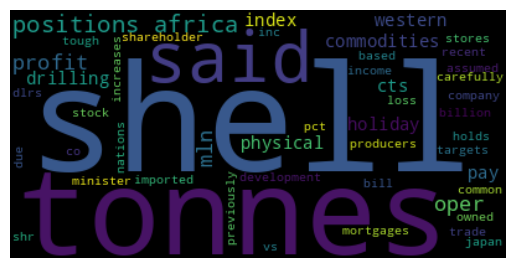

In [ ]:
F = ' '.join([index_to_word[x] for x in x_train_raw[50]])

wordcloud = WordCloud().generate(F)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

To train a recurrent neural network, we need to _pad_ all our word sequences . It means that we will just insert zeroes in front of each sequence to make their length equal.

Here is how padding works:

In [ ]:
sequence = [[1], [2, 3], [4, 5, 6]]
print("Raw sequence is:")
print(sequence)
print("Padded sequence is:")
print(tf.keras.preprocessing.sequence.pad_sequences(sequence))
print(type(tf.keras.preprocessing.sequence.pad_sequences(sequence)))

Raw sequence is:
[[1], [2, 3], [4, 5, 6]]
Padded sequence is:
[[0 0 1]
 [0 2 3]
 [4 5 6]]
<class 'numpy.ndarray'>


Now we will pad our data. Here, we will also do an extra - we will pad our sequences to a certain length and trim those that are longer. This is needed to speed up the training (longer sequences will result in longer time to train our recurrent neural network)

In [ ]:
max_length = 200
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train_raw, maxlen = max_length)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test_raw, maxlen = max_length)
print("dim (X train) =", x_train.shape)

dim (X train) = (8982, 200)


The last step in data pre-processing is to one-hot encode values of the response variable (it is a categorical variable wih 46 classes).

In [ ]:
y_train = keras.utils.to_categorical(y_train_raw, num_classes)
y_test = keras.utils.to_categorical(y_test_raw, num_classes)

print("Sample of y_train we will use in the actual model training:")
print(y_train[:3, :8])
print("dim(Y train) =", y_train.shape)
print("dim(Y test) =", y_test.shape)

Sample of y_train we will use in the actual model training:
[[0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]
dim(Y train) = (8982, 46)
dim(Y test) = (2246, 46)


One last thing to understand about recurrent neural networks for text classification is that the first thing that our model should do is to convert sequences of numbers that encode words to sequences of vectors. In other words, our model needs to construct its own word embeddings similar to GloVe. To do it, we will add a special first layer called "embedding layer".

_Remark_: if we used recurrent neural networks for some other type of sequential data, we probably wouldn't need an embedding layer. For example, if we needed to predict the price of some stock exchange index using the history of several other indices, then our input data would just be a sequence of vectors and we wouldn't need an embedding layer (we still would need to pre-process the data).

We will create a simple model with 50-dimensional embeddings and an LSTM layer with 20 units. Feel free to change these numbers to smaller ones if this takes too much time on your computer to run (takes 204 seconds on Fedor's MacBook Pro with M1 chip).

Here we define our model

In [ ]:
### For reproducibility:

seed(42)
tf.random.set_seed(496)

### Now define our model
model = Sequential()
model.add(Embedding(vocab_size, 50, input_length=max_length))
model.add(LSTM(20, return_sequences = False))
model.add(Dense(num_classes, activation='sigmoid'))
# compile the model
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['accuracy'])
# summarize the model
print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_27 (LSTM)                       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


And now we will train it. Note that it takes considerable time to train a recurrent neural network even on a small dataset:

In [ ]:
num_epochs = 5

start = time.time()

history = model.fit(x_train, y_train, \
                    validation_data=(x_test, y_test), \
                    epochs = num_epochs, verbose=1)

end = time.time()
print("Training the model took", np.round(end - start), "s")

score = model.evaluate(x_test, y_test)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.0098 - loss: 0.2701 - val_accuracy: 0.0111 - val_loss: 0.0376
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0101 - loss: 0.0336 - val_accuracy: 0.0111 - val_loss: 0.0272
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0101 - loss: 0.0263 - val_accuracy: 0.0111 - val_loss: 0.0246
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0101 - loss: 0.0243 - val_accuracy: 0.0111 - val_loss: 0.0235
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0101 - loss: 0.0233 - val_accuracy: 0.0111 - val_loss: 0.0229
Training the model took 26.0 s
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0107 - loss: 0.0229
Test loss: 0.022949382662773132
Test accuracy: 0.01113089919090271


In [ ]:
def plot_train_history(hist):
    train_history = pd.DataFrame(hist.history)
    train_history["epoch"] = np.arange(num_epochs) + 1
    fig = px.line(train_history, x = 'epoch', y = ['accuracy', 'val_accuracy'])
    return fig

plot_train_history(history).show()

# Your work

Please insert your codes and your explanations below - they will be graded.

## Question 1

Plot a histogram of the number of words in news articles.

In [ ]:
## Write your code here

df_article_info = pd.DataFrame({'index': np.arange(x_train.shape[0]),\
              'article length': article_lengths})

px.histogram(df_article_info, x = 'article length')

***ANS:***

In [ ]:
# Create the histogram
fig = px.histogram(x=article_lengths, nbins=250, labels={'x': 'Number of Words', 'y': 'Number of Articles'},
                   title='Histogram of Article Lengths', opacity=0.7)

# Show the plot
fig.show()

## Question 2

Plot the word cloud of all the texts in class "4". You will get a higher score if you do it without nested loops.

_Bonus question:_ can you plot such word clouds for all 46 classes on one diagram? They should be arranged on a $7\times 7$ grid?

_Another bonus question:_ can you figure out what are the 46 classes? You are allowed to use google.

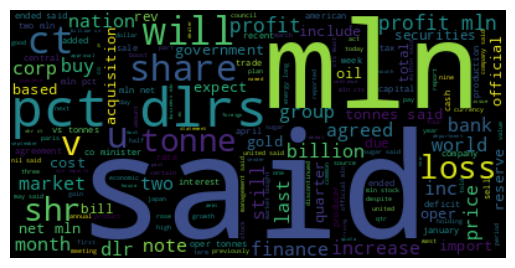

In [ ]:
## First, we find positions at which we have class 4
index_class_4 = np.where(y_train_raw == 4)

# Now we subset the list x_train_raw by taking elements at positions we need.
# Note that x_train_raw[index_class_4] is a list of lists.
# To infold it into a list of numbers, we will concatenate them into one list.
# Concatenation of lists in Python is just +.
# So we will just apply the sum.
# But in order to tell Python that we are taking concatenation
# rather than the sum of numbers, we will set the initial value of the sum
# to the empty list [].
word_codes_class_4 = sum(x_train_raw[index_class_4], [])

# And now the word cloud
all_articles_class_4 = ' '.join([index_to_word[x] for x in word_codes_class_4])

wordcloud = WordCloud().generate(all_articles_class_4)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

***ANS:***

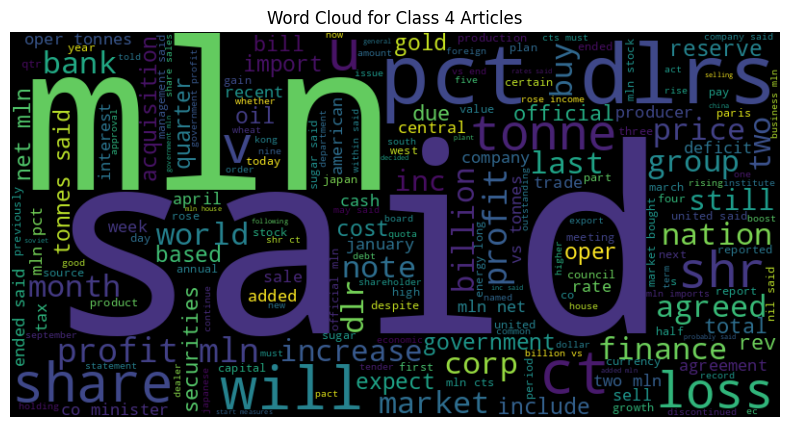

In [ ]:
# Extract all articles in class 4
class_4_indices = np.where(y_train_raw == 4)[0]
class_4_texts = np.concatenate([x_train_raw[i] for i in class_4_indices])  # Flatten without nested loops

words = [index_to_word.get(word_id,'') for word_id in class_4_texts]

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(words))

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Class 4 Articles")
plt.show()


In [ ]:
fig, axes = plt.subplots(7, 7, figsize=(20, 20))

for class_label in range(46):
    ax = axes[class_label // 7, class_label % 7]

    # Extract words for the class
    class_indices = np.where(y_train_raw == class_label)[0]
    class_texts = np.concatenate([x_train_raw[i] for i in class_indices])
    words = [index_to_word.get(word_id, '') for word_id in class_texts]

    # Generate word cloud
    wordcloud = WordCloud(width=300, height=300, background_color='black').generate(' '.join(words))

    # Plot
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Class {class_label}")
    ax.axis("off")

# Hide any unused subplots (for slots > 46)
for i in range(46, 49):  # 49 = 7x7
    fig.delaxes(axes[i // 7, i % 7])

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

According to [Stephen Bauer's GitHub repo](https://github.com/SteffenBauer/KerasTools/tree/master/Reuters_Analysis), 46 classes are:<br>

```
['cocoa','grain','veg-oil','earn','acq','wheat','copper','housing','money-supply',
 'coffee','sugar','trade','reserves','ship','cotton','carcass','crude','nat-gas',
 'cpi','money-fx','interest','gnp','meal-feed','alum','oilseed','gold','tin',
 'strategic-metal','livestock','retail','ipi','iron-steel','rubber','heat','jobs',
 'lei','bop','zinc','orange','pet-chem','dlr','gas','silver','wpi','hog','lead']
```



## Question 3

The construction and the training of the recurrent neural model Fedor trained above has some serious errors. Besides, the model was not regularized. Define a correct new model, regularize it, train, report test accuracy, and plot the history of training.

Answer the following question: based on your plot, does your model overfit, underfit, or fits just right?

_Remark:_ we don't have time in class to properly fine-tune the model, especially since it takes considerable time to retrain it. You just need to know how to write the Python code correctly and get some rough idea of model diagnostics based on a plot of its training history.

We need to change the activation function to softmax and the loss function to categorical cross-entropy. Besides, we will introduce the dropout regularization with probability $0.2$.

Here is the correct code:

In [ ]:
### Write your code here

### For reproducibility:

seed(42)
tf.random.set_seed(496)

### Now define our model
model = Sequential()
model.add(Embedding(vocab_size, 50, input_length=max_length))
model.add(LSTM(20, return_sequences = False))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))
# compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# summarize the model
print(model.summary())

num_epochs = 5

start = time.time()

history = model.fit(x_train, y_train, \
                    validation_data=(x_test, y_test), \
                    epochs = num_epochs, verbose=1)

end = time.time()
print("Training the model took", np.round(end - start), "s")

score = model.evaluate(x_test, y_test)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

plot_train_history(history).show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.3339 - loss: 2.9838 - val_accuracy: 0.4354 - val_loss: 2.0835
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4792 - loss: 1.9626 - val_accuracy: 0.5338 - val_loss: 1.7835
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4935 - loss: 1.7746 - val_accuracy: 0.5668 - val_loss: 1.7238
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5762 - loss: 1.5269 - val_accuracy: 0.5766 - val_loss: 1.6407
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6195 - loss: 1.3801 - val_accuracy: 0.5801 - val_loss: 1.6248
Training the model took 22.0 s
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5930 - loss: 1.5753
Test loss: 1.6248427629470825
Test accuracy: 0.5801424980163574


***ANS:***

Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3189 - loss: 3.0213 - val_accuracy: 0.4497 - val_loss: 2.0596
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4860 - loss: 1.9523 - val_accuracy: 0.5677 - val_loss: 1.7563
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5347 - loss: 1.8098 - val_accuracy: 0.4889 - val_loss: 1.9218
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5283 - loss: 1.7209 - val_accuracy: 0.5583 - val_loss: 1.7150
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6047 - loss: 1.5453 - val_accuracy: 0.5592 - val_loss: 1.7296
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5769 - loss: 1.6969
Test Accuracy: 0.5592


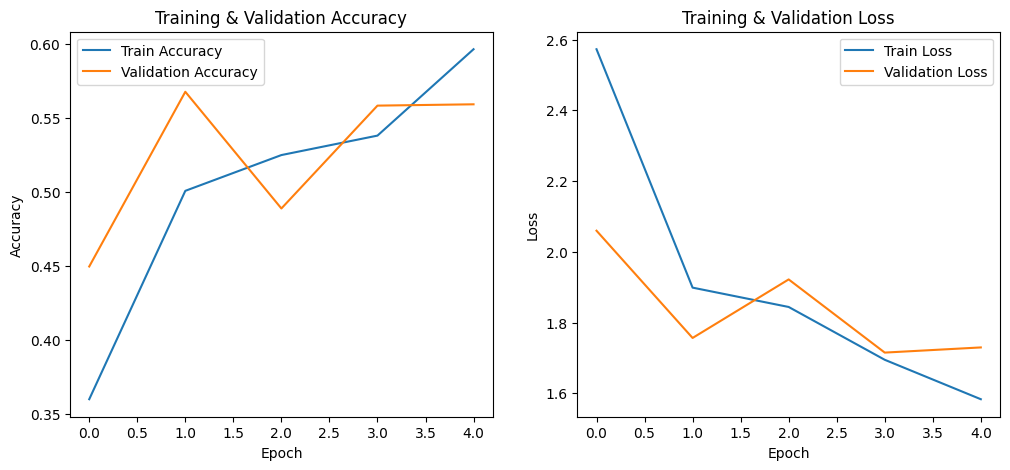

In [71]:
seed(42)
tf.random.set_seed(496)

# Define model parameters
embedding_dim = 50
lstm_units = 20
dropout_rate = 0.2
l2_lambda = 0.001  # L2 regularization


# Define regularized model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
   LSTM(lstm_units, return_sequences=False, kernel_regularizer=regularizers.l2(l2_lambda)),
    # LSTM(lstm_units, return_sequences=False),

    Dropout(dropout_rate),  # Dropout for regularization
    Dense(num_classes, activation='softmax')  # Softmax for multi-class classification
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=num_epochs, batch_size=32, validation_data=(x_test, y_test), verbose=1)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()


The model underfits - accuracy is too low. Besides, validation accuracy is higher than training accuracy, which shouldn't be the case.

## Question 4

Suggest strategies for how to make the model more accurate in practice. If you have more time and resources to train the model, what would you do?

One of possible approaches is to train a model with more than one LSTM layer. You will get a higher score if you write a working Python code for doing it.

_Answer_

To make the model more accurate, we can do the following: increase the number of units in LSTM layers and stack several LSTM layers on top of one another. It also makes sense to add a few dense layers on top of LSTM. It will probably help if we use pre-trained word embeddings.

We would need to find a good combination of hyperparameters, such as weight decay. And we could experiment with different optimizers. To do it, we will try training many models with different combinations of hyperparameters. To make this process reasonably fast, we will need to create a small subset of the training set just for model tuning and we will pick a good combination of hyperparameters that doesn't lead to overfitting and yet yields a reasonable increase in accuracy over a few epochs. This will be done by a junior data scientist or, probably, a graduate student.

And one a good combination of hyperparameters is found, we train the model for many epochs and that'll take a long time.

Below is a model with 2 LSTM layers and `rmsprop` optimizer instead of `adam` - just for demonstration. Note that the first LSTM layers has the option `return_sequences = True`.

In [ ]:
### Write your code here

### For reproducibility:

seed(42)
tf.random.set_seed(496)

### Now define our model
model2 = Sequential()
model2.add(Embedding(vocab_size, 100, input_length=max_length))
model2.add(LSTM(30, return_sequences = True))
model2.add(LSTM(30, return_sequences = False))
model2.add(Dropout(0.25))
model2.add(Dense(100, activation='relu'))
model2.add(Dense(50, activation='relu'))
model2.add(Dense(num_classes, activation='softmax'))
# compile the model
model2.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
# summarize the model
print(model2.summary())

num_epochs = 5

start = time.time()

history = model2.fit(x_train, y_train, \
                    validation_data=(x_test, y_test), \
                    epochs = num_epochs, verbose=1)

end = time.time()
print("Training the model took", np.round(end - start), "s")

score = model2.evaluate(x_test, y_test)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

plot_train_history(history).show()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4010 - loss: 2.3723 - val_accuracy: 0.5067 - val_loss: 1.8259
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5292 - loss: 1.7107 - val_accuracy: 0.5316 - val_loss: 1.7258
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5704 - loss: 1.5464 - val_accuracy: 0.5557 - val_loss: 1.6771
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6090 - loss: 1.4154 - val_accuracy: 0.5917 - val_loss: 1.5862
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6413 - loss: 1.3099 - val_accuracy: 0.6153 - val_loss: 1.5523
Training the model took 40.0 s
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6236 - loss: 1.5117
Test loss: 1.552256464958191
Test accuracy: 0.6153160929679871


***ANS:***
1. Increase Model Complexity<br>
Your current LSTM model might not be expressive enough. <br>
✅ More LSTM units: Increase from 50 to a larger value (e.g. 64).<br>
✅ Stacking multiple LSTM layers: Add another LSTM layer before the dense layer.<br>
✅ Bidirectional LSTM: Helps capture dependencies in both directions.<br>

2. Train for More Epochs<br>
✅ Your model might not have trained long enough. Try increasing epochs to 20-50 while monitoring validation loss.<br>

3. Use a Larger Embedding Dimension<br>
✅ The embedding layer maps words into a dense vector space. Using embedding_dim = 100 or 200 (instead of 50) can improve representation.



Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.3274 - loss: 2.9716 - val_accuracy: 0.3620 - val_loss: 2.4651
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3728 - loss: 2.3885 - val_accuracy: 0.4933 - val_loss: 2.0572
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5062 - loss: 1.9268 - val_accuracy: 0.3851 - val_loss: 2.2580
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5169 - loss: 1.9222 - val_accuracy: 0.5548 - val_loss: 1.7786
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5690 - loss: 1.6789 - val_accuracy: 0.5637 - val_loss: 1.7640
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5785 - loss: 1.6402 - val_accuracy: 0.5695 - val_loss: 1.7306
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5989 - loss: 1.5868 - val_accuracy: 0.5663 - val_loss: 1.7322
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6230 - loss: 1.5287 - val_accu

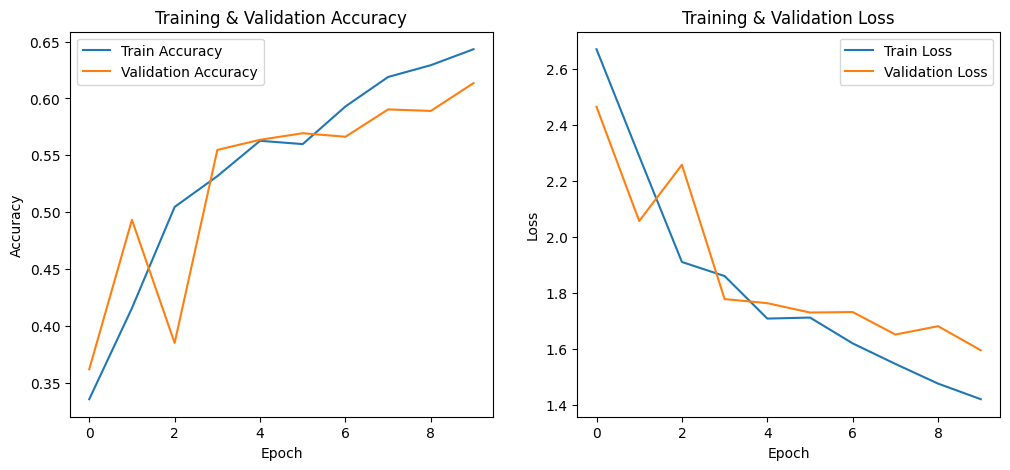

In [ ]:
# Define model parameters
seed(42)
tf.random.set_seed(496)

embedding_dim = 50
lstm_units1 = 64
lstm_units2 = 64
dropout_rate = 0.2
l2_lambda = 0.001  # L2 regularization
num_epochs = 10
batch_size = 64

# Define regularized model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(lstm_units1, return_sequences=True, kernel_regularizer=regularizers.l2(l2_lambda)),
    Dropout(dropout_rate),  # Dropout after first LSTM

    LSTM(lstm_units2, return_sequences=False, kernel_regularizer=regularizers.l2(l2_lambda)),
    Dropout(dropout_rate),  # Additional dropout layer

    Dense(num_classes, activation='softmax')  # Softmax for multi-class classification
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=num_epochs, batch_size=batch_size, validation_data=(x_test, y_test), verbose=1)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()


### Question 5

This is a theoretical problem about artificial neural networks.

Here, we are considering fully connected artificial
neural networks with the activation function $f(x)=x^2$
in all hidden layers. The output layer has one unit
and the identity activation function, i.e.,
this is a neural network for regression.

(a) Construct a neural network with a 1-dimensional input $x$, one hidden layer and output $h(x)=x$

(b) Construct a neural network with
a 2-dimensional input $(x_1,x_2)$ and output
$h(x_1,x_2)=x_1\cdot x_2$.

If you don't have time to insert a picture to this document, just draw it on a piece of paper and hand in to Fedor.

_Answer_

(a) We have, $x=(x+0.5)^2-x^2-0.25$. Thus we can use 2 units in the hidden layer, one with zero bias, one with bias $0.5$ as follows:
$$
W^{(1)}=
\begin{bmatrix}
1 \\
1
\end{bmatrix},
\quad
b^{(1)}=
\begin{bmatrix}
0.5 \\
0
\end{bmatrix}
$$
Then we will get
$$
z^{(1)}=
\begin{bmatrix}
x+0.5 \\
x
\end{bmatrix},\qquad
a^{(1)}=
\begin{bmatrix}
(x+0.5)^2 \\
x^2
\end{bmatrix}
$$
In the output layer, we have
$$
W^{(2)}=
\begin{bmatrix}
1 & -1
\end{bmatrix},\quad
b^{(2)}=-0.25
$$
and hence
$$
a^{(2)}=z^{(2)}=W^{(2)}a^{(1)}+b^{(2)}
=(x+0.5)^2-x^2-0.25=x
$$

(b) We have
$$
x_1x_2=\frac{(x_1+x_2)^2-x_1^2-x_2^2}{2}
$$
Thus we can construct an artificial neural network with one hidden layer, zero bias and weight matrix
$$
\begin{bmatrix}
1 & 1 \\
1 & 0 \\
0 & 1
\end{bmatrix}
$$
In the output layer, weights are $1/2,-1/2,-1/2$ and the zero bias.


## Question 6

Suppose that we have a dataset for text classification of the following size:

* Number of training examples = 500000

* Vocabulary size = 40000

* Maximum lengh of a document = 5000

And we want to develop a deep learning model to do it. Let's say that our model will be based on 200-dimensional embeddings and 3 LSTM layers with 128 units in each layer.

Estimate the cost of fine-tuning the model (i.e., finding a good combination of training hyperparameters) and the cost of training such a model on the cloud.

_Answer_

To fine-tune the model, we need to try a lot of different combinations of hyperparameters. Let's say we will try 10 different model architectures, 10 different values for weight decay, and 3 optimizers. The total number of models we need to try to find a good combination is 300. If training each of them takes 5 minutes, then the total time is 25 hours. It'll probably take another day to set-up the process and one more day for sudden delays, i.e., fine-tuning will take around 3 days. This can be done by a junior data scientist, good internt or a graduate student, or we can hire a data science company for that.

What is the average salary of a junior data scientist? Let's do some online search. According to [THIS INFO](https://www.glassdoor.sg/Salaries/junior-data-scientist-salary-SRCH_KO0,21.htm#:~:text=Scientist%20in%20Singapore%3F-,The%20highest%20salary%20for%20a%20Junior%20Data%20Scientist%20in%20Singapore,Singapore%20is%20%244%2C300%20per%20month.), the average base pay of a junior data scientist is 5876 per month. It rounds to about 300 SGD per day. Thus a reasonable estimate for the cost of tuning the model is probably around 1000 SGD if we have a data scientist, smaller if we have a good intern or a graduate student who is working part-time, and larger if we hire a data science company.

It is clear that the training time increases linearly with the training set size - that's just how gradient descent works. It means that we expect training time to be
$$
\frac{500000}{25000}=20
$$
times longer than what we had just because the size of the training set 20 times bigger. Besides, we will have a bigger model. It's not clear now the training time scales with the model size though, especially since increase in the model size happens to be in the embedding layer (it is 4-fold) but the embedding layer trains faster than LSTM layers. The right way to figure it out is to just actually try such a big model and see how long it takes to train it for one epoch, but there is not time for it in class. So we will for simplicity say that the training time is expected to be 10 times longer due to the increase in model size. And, finally, we want to train our model for more epochs, let's say, 500 epochs.

On the other hand, TPU that are used for training models on the cloud are faster than our computer for prototyping. How much faster, exactly? A quick google search shows [this info](https://cloud.google.com/blog/products/gcp/quantifying-the-performance-of-the-tpu-our-first-machine-learning-chip), so let's say that training on the cloud is going to be 20 times faster than training on the local computer. Training our simple model took 2 minutes, so we estimate the training time on the cloud to be
$$
\frac{1}{12}\times
\frac{1}{20}\times
2\times 20\times 10\times 100\approx 167
$$
hours, i.e., one week.

There is a price calculator for google cloud [HERE](https://cloud.google.com/products/calculator#id=56f73b17-453d-4260-bac9-357b2fd94312). According to Fedor's computation, the price of model training is USD 539.82 = SGD 724.77.

## Question 7

Where in the financial industry can we make use of deep learning models for text classification? How can we estimate the net gain from implementing such models?

Fedor will leave this blank and look first at answers submitted by students :)